# 🩺 The Hypertension Code: EDA, CatBoost, SHAP

#### **Hypertension Detection: An End-to-End Analysis**

#### Project Overview: Hypertension Risk Prediction

Welcome to this end-to-end analysis of hypertension risk! This notebook documents a complete data science workflow, moving from raw data to a highly accurate and fully interpretable machine learning model. Our objective is not merely to predict hypertension but to uncover the key lifestyle and biomedical factors that drive it

**Notebook Workflow**

This project is structured to follow a standard, rigorous data science pipeline. Here's a step-by-step guide to what you'll find below:

1.  **Exploratory Data Analysis (EDA):** We begin by performing a deep dive into the dataset, visualizing the distributions of both numerical and categorical features to uncover initial patterns and relationships.

2.  **Strategic Imputation:** This critical stage addresses a major data quality issue. We analyze the 40% missing data in the Medication column, hypothesizing that "missing" is a meaningful category, and strategically impute it as "No Medication".

3.  **Data Preprocessing:** We prepare the data for modeling by encoding categorical features, ensuring our chosen model can interpret all inputs correctly.

4.  **Model Building & Tuning:** A CatBoostClassifier is selected for its superior handling of categorical data. We then use GridSearchCV to systematically tune its hyperparameters for optimal performance.

5.  **Model Evaluation:** We rigorously assess our tuned model's performance on unseen test data, achieving 99% accuracy. We analyze the confusion matrix to confirm its effectiveness in minimizing critical errors.

6.  **Model Interpretation (XAI):** Finally, we use SHAP (SHapley Additive exPlanations) to open up the "black box." This allows us to understand exactly why our model makes its predictions, revealing the true drivers of hypertension risk.

**Project Aim**

Our primary objectives for this analysis are:

* To build a highly robust and accurate machine learning model capable of classifying a patient's hypertension status.

* To identify the most significant lifestyle and biomedical factors that predict hypertension.

* To demonstrate how a context-aware imputation strategy can be more powerful than complex algorithms.

* To deliver a final model that is not only accurate but also fully interpretable using modern Explainable AI (XAI) technique

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import  warnings
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import shap

In [2]:
!pip install ydata-profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.0/679.0 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=d461049bf26dfa03c3ae423e2c2df7abfc9f95aba0f91100b92bc503455cfe01
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.0
    Uninstalling scipy-1.16.0:
     

# Reading & Analysing Data

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/hypertension-risk-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/hypertension-risk-prediction-dataset


In [3]:
from google.colab import files

uploaded = files.upload()

Saving hypertension_dataset.csv to hypertension_dataset.csv


In [4]:
df = pd.read_csv('hypertension_dataset.csv')

df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [5]:
df.shape

(1985, 11)

In [6]:
df.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


In [8]:
df.isna().sum()

,0
Age,0
Salt_Intake,0
Stress_Score,0
BP_History,0
Sleep_Duration,0
BMI,0
Medication,799
Family_History,0
Exercise_Level,0
Smoking_Status,0


# Pandas Profiling

In [9]:
report = ProfileReport(df)
report.to_file('ydata_profiling_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 35.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Handling Missing Data

In [10]:
print(f"The missing rows percentage is in Medication Column is -> {round((df['Medication'].isna().sum()/1985)*100,2)}%")

The missing rows percentage is in Medication Column is -> 40.25%


In [11]:
df['Medication'].fillna('No Medication', inplace=True)
df['Medication'].head()

,Medication
0,No Medication
1,No Medication
2,No Medication
3,ACE Inhibitor
4,Other


**Why** KNNImputer **Was Not the Right Tool for** the Medication **Column**

🤔 The Problem: What "Missing" Really Meant

* Our Medication column had over 40% missing values. Before using a complex imputer, the most important step was to ask why the data was missing.

* In a medical context, a blank field for medication does not usually mean the data was lost. It implies a meaningful answer: the patient is on "No Medication".

* This is a classic case of Missing Not At Random (MNAR), where the absence of data is itself a valuable piece of information.

✅ Our Strategy: Treat "Missing" as Information

We chose to replace the missing values with a new category, "No Medication".

* **Why it Worked:** This approach respected the real-world meaning of the data. It correctly taught our model that there's a group of patients who are not taking medication, which is a powerful predictive signal.

* **The Result:** This simple, logical step was a key reason our model achieved an exceptional 99% accuracy.

❌ The Flaw of Using KNNImputer or IterativeImputer Here

These advanced tools work on a fundamentally different assumption—that the data is **Missing At Random (MAR)**.

* **What They Would Have Done:** A tool like KNNImputer would have looked at a patient with a missing value and said, "This person looks like other patients who are on 'Beta Blockers', so I'll guess they are on 'Beta Blockers' too."

* **Why This Is Wrong:** This process would have actively destroyed the crucial "No Medication" information. It would have filled 40% of our dataset with educated guesses, overwriting the truth and teaching our model incorrect patterns.

**In conclusion, understanding the context of your data is more important than the complexity of your tools.** For this dataset, recognizing that "missing" meant "no" was the correct and most powerful approach.

# Categorical Features EDA

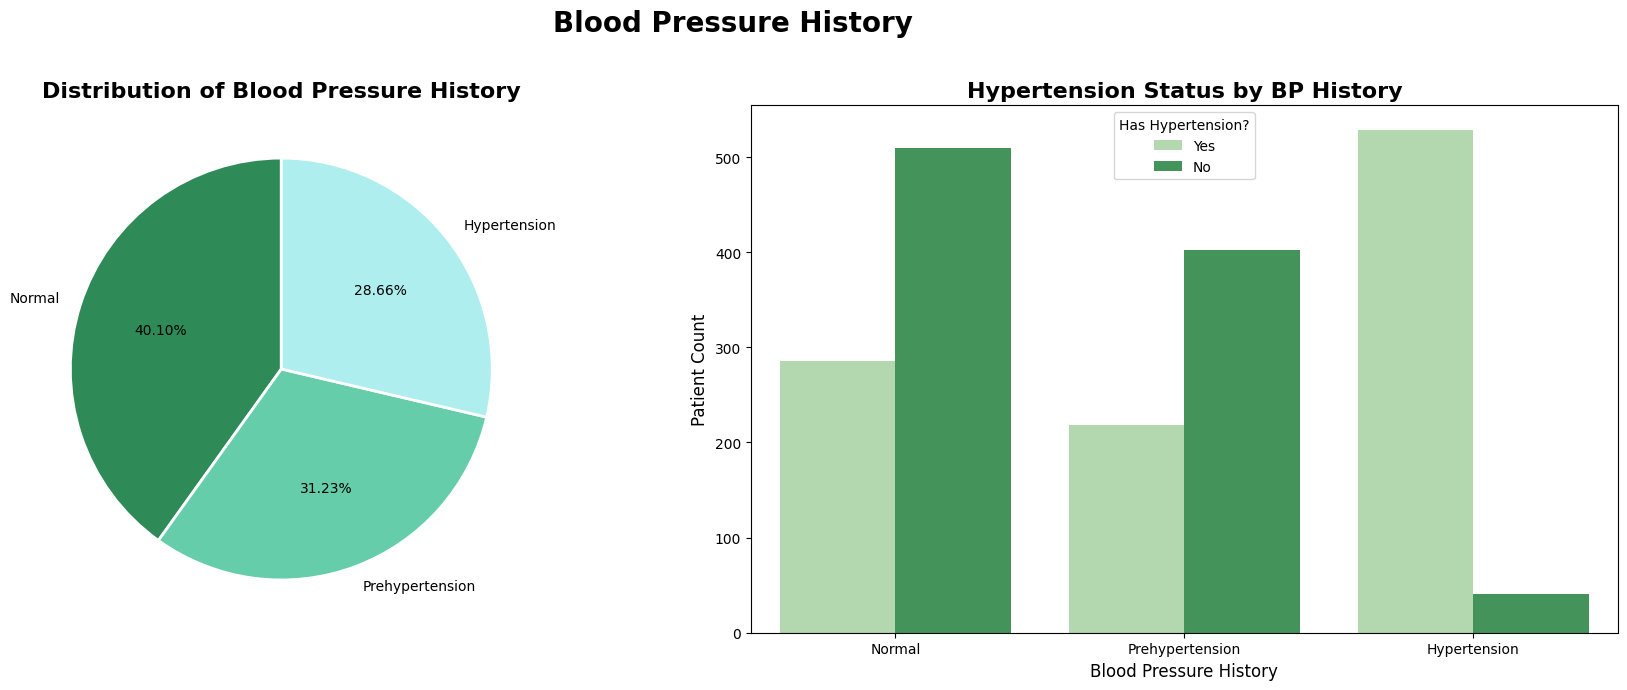

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
bp_counts = df['BP_History'].value_counts()
pie_colors = ['#2E8B57', '#66CDAA', '#AFEEEE']

# pie chart
axes[0].pie(bp_counts,
            labels=bp_counts.index,
            autopct='%.2f%%',
            startangle=90,
            colors=pie_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[0].set_title('Distribution of Blood Pressure History', fontsize=16, fontweight='bold')

# Bar Plot
bar_palette = "Greens"
sns.countplot(ax=axes[1],
              data=df,
              x='BP_History',
              hue='Has_Hypertension',
              palette=bar_palette,
              order=bp_counts.index)

axes[1].set_title('Hypertension Status by BP History', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Blood Pressure History', fontsize=12)
axes[1].set_ylabel('Patient Count', fontsize=12)
axes[1].legend(title='Has Hypertension?')

plt.suptitle('Blood Pressure History', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

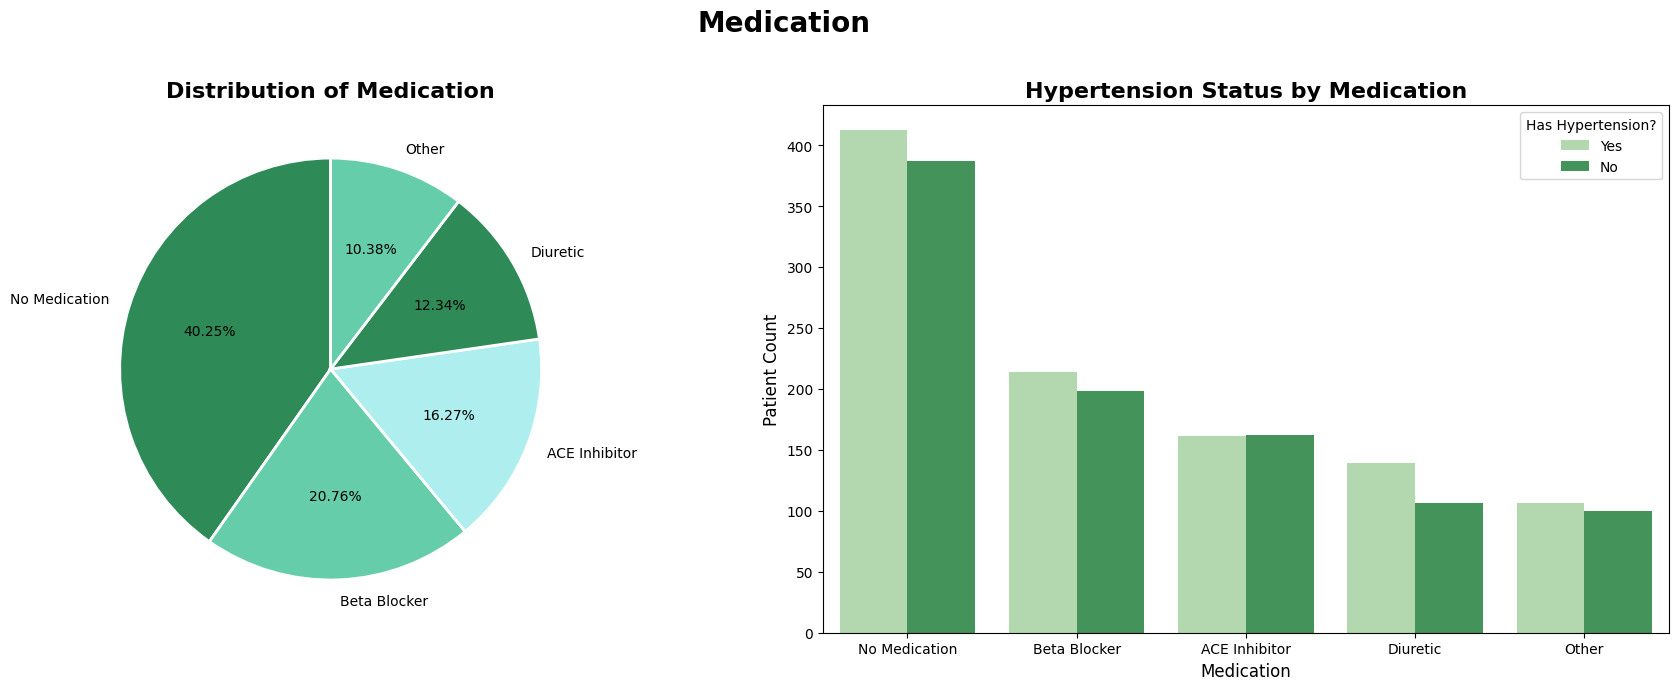

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
bp_counts = df['Medication'].value_counts()
pie_colors = ['#2E8B57', '#66CDAA', '#AFEEEE']

# pie chart
axes[0].pie(bp_counts,
            labels=bp_counts.index,
            autopct='%.2f%%',
            startangle=90,
            colors=pie_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[0].set_title('Distribution of Medication', fontsize=16, fontweight='bold')

# Bar Plot
bar_palette = "Greens"
sns.countplot(ax=axes[1],
              data=df,
              x='Medication',
              hue='Has_Hypertension',
              palette=bar_palette,
              order=bp_counts.index)

axes[1].set_title('Hypertension Status by Medication', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Medication', fontsize=12)
axes[1].set_ylabel('Patient Count', fontsize=12)
axes[1].legend(title='Has Hypertension?')

plt.suptitle('Medication', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

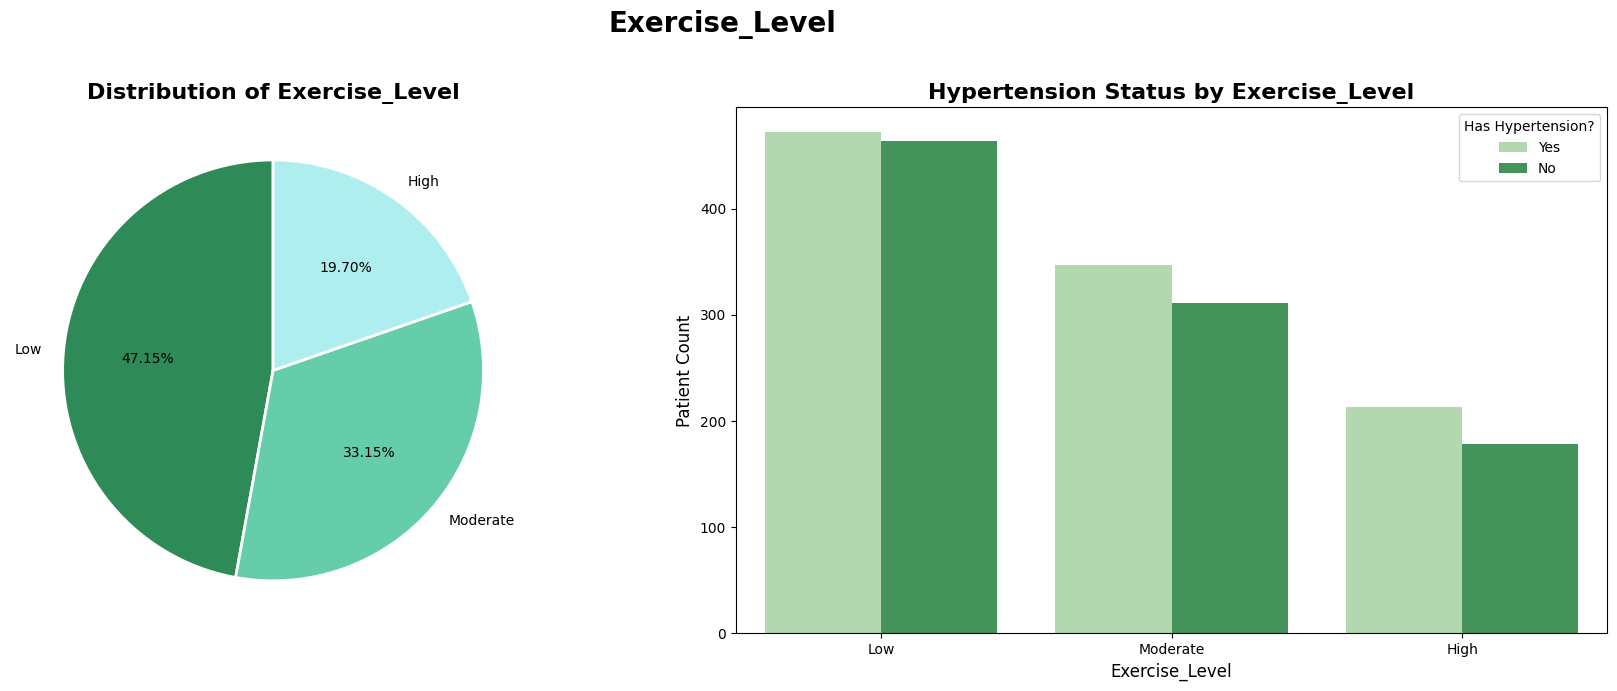

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
bp_counts = df['Exercise_Level'].value_counts()
pie_colors = ['#2E8B57', '#66CDAA', '#AFEEEE']

# pie chart
axes[0].pie(bp_counts,
            labels=bp_counts.index,
            autopct='%.2f%%',
            startangle=90,
            colors=pie_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[0].set_title('Distribution of Exercise_Level', fontsize=16, fontweight='bold')

# Bar Plot
bar_palette = "Greens"
sns.countplot(ax=axes[1],
              data=df,
              x='Exercise_Level',
              hue='Has_Hypertension',
              palette=bar_palette,
              order=bp_counts.index)

axes[1].set_title('Hypertension Status by Exercise_Level', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Exercise_Level', fontsize=12)
axes[1].set_ylabel('Patient Count', fontsize=12)
axes[1].legend(title='Has Hypertension?')

plt.suptitle('Exercise_Level', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

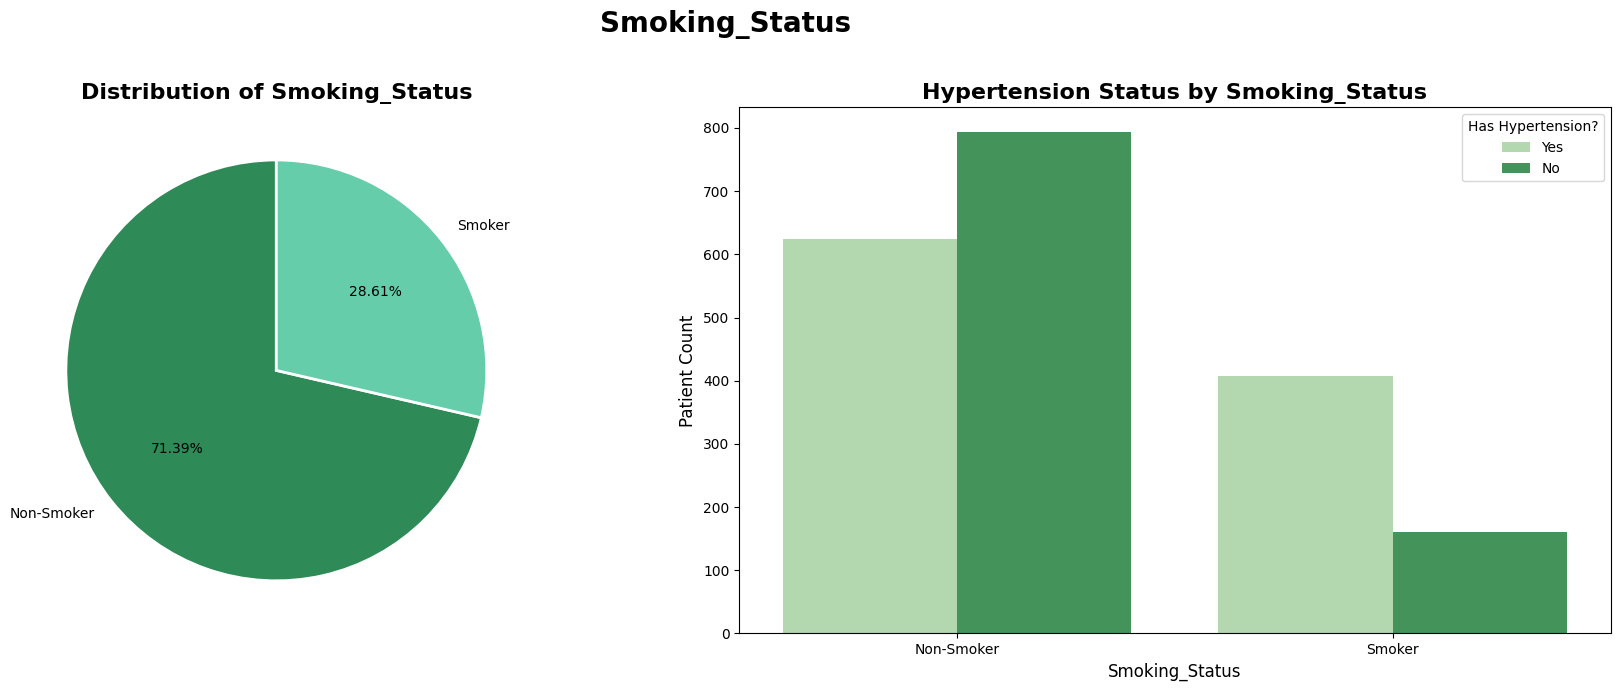

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
bp_counts = df['Smoking_Status'].value_counts()
pie_colors = ['#2E8B57', '#66CDAA', '#AFEEEE']

# pie chart
axes[0].pie(bp_counts,
            labels=bp_counts.index,
            autopct='%.2f%%',
            startangle=90,
            colors=pie_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[0].set_title('Distribution of Smoking_Status', fontsize=16, fontweight='bold')

# Bar Plot
bar_palette = "Greens"
sns.countplot(ax=axes[1],
              data=df,
              x='Smoking_Status',
              hue='Has_Hypertension',
              palette=bar_palette,
              order=bp_counts.index)

axes[1].set_title('Hypertension Status by Smoking_Status', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Smoking_Status', fontsize=12)
axes[1].set_ylabel('Patient Count', fontsize=12)
axes[1].legend(title='Has Hypertension?')

plt.suptitle('Smoking_Status', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

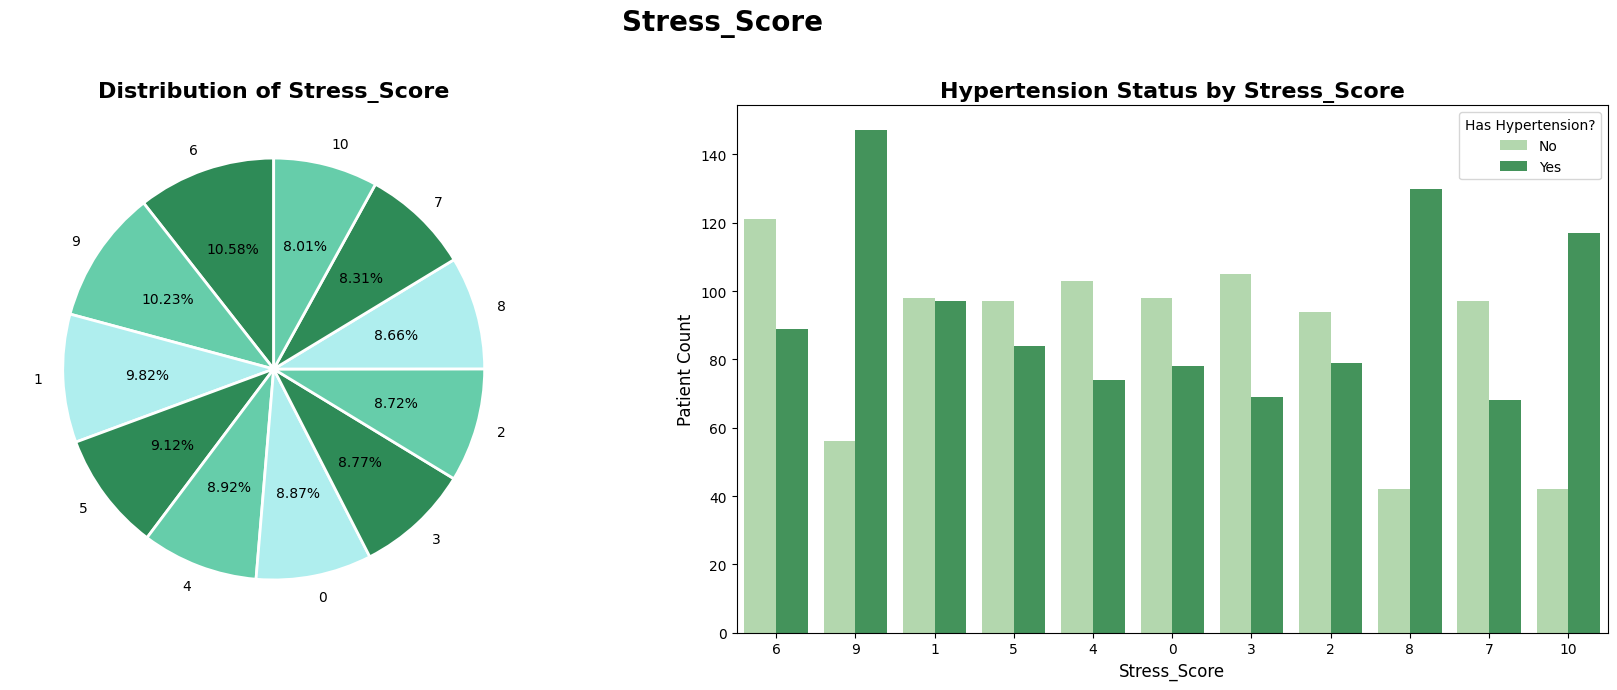

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
bp_counts = df['Stress_Score'].value_counts()
pie_colors = ['#2E8B57', '#66CDAA', '#AFEEEE']

# pie chart
axes[0].pie(bp_counts,
            labels=bp_counts.index,
            autopct='%.2f%%',
            startangle=90,
            colors=pie_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[0].set_title('Distribution of Stress_Score', fontsize=16, fontweight='bold')

# Bar Plot
bar_palette = "Greens"
sns.countplot(ax=axes[1],
              data=df,
              x='Stress_Score',
              hue='Has_Hypertension',
              palette=bar_palette,
              order=bp_counts.index)

axes[1].set_title('Hypertension Status by Stress_Score', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Stress_Score', fontsize=12)
axes[1].set_ylabel('Patient Count', fontsize=12)
axes[1].legend(title='Has Hypertension?')

plt.suptitle('Stress_Score', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

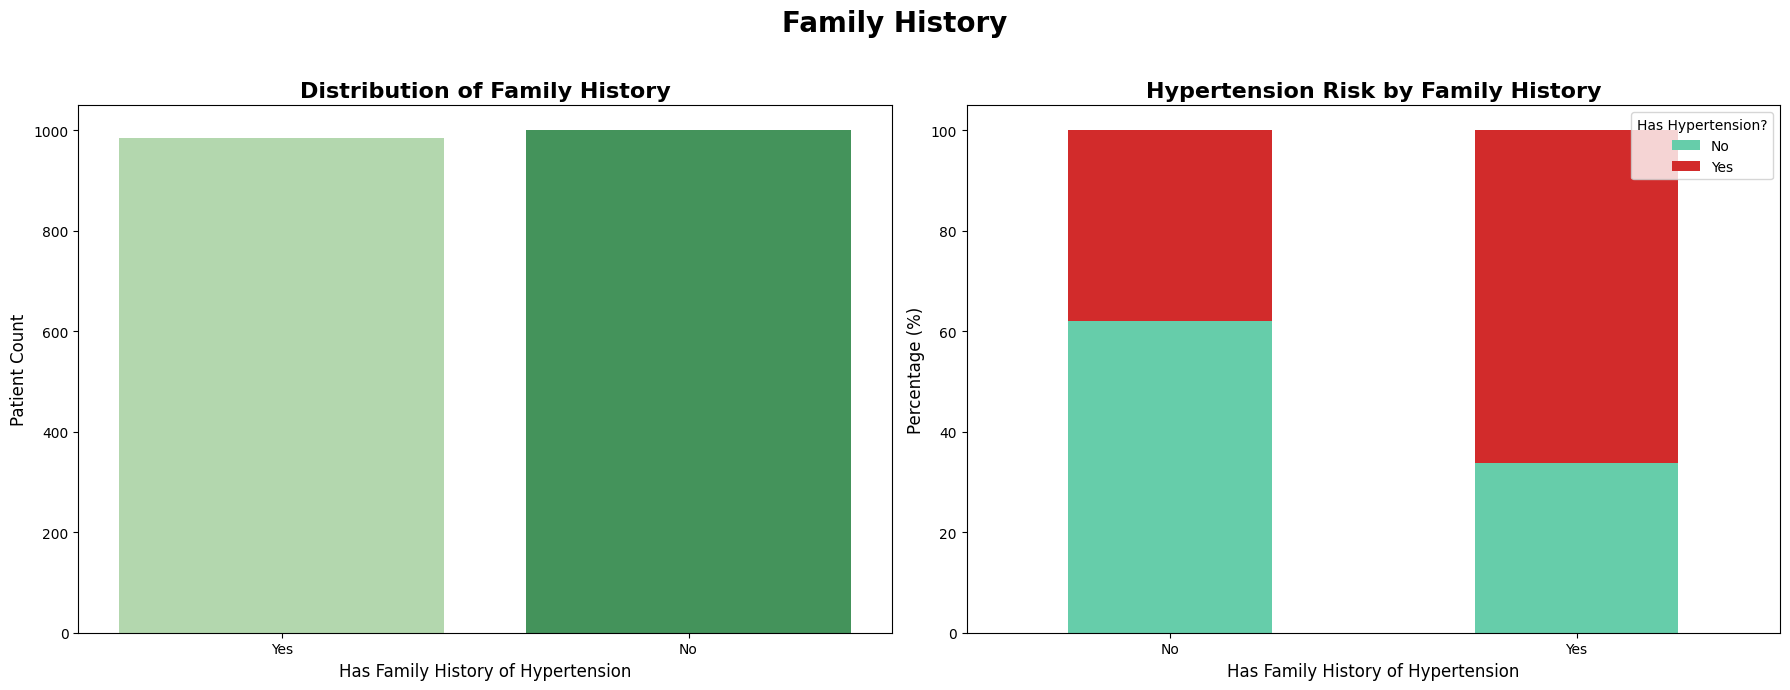

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.countplot(ax=axes[0],
              data=df,
              x='Family_History',
              palette='Greens')

axes[0].set_title('Distribution of Family History', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Has Family History of Hypertension', fontsize=12)
axes[0].set_ylabel('Patient Count', fontsize=12)

crosstab_norm = pd.crosstab(df['Family_History'],
                           df['Has_Hypertension'],
                           normalize='index') * 100

# Plot the 100% stacked bar chart
crosstab_norm.plot(kind='bar',
                   stacked=True,
                   ax=axes[1],
                   color=['#66CDAA', '#D22B2B'])

axes[1].set_title('Hypertension Risk by Family History', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Has Family History of Hypertension', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Has Hypertension?', loc='upper right')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('Family History', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

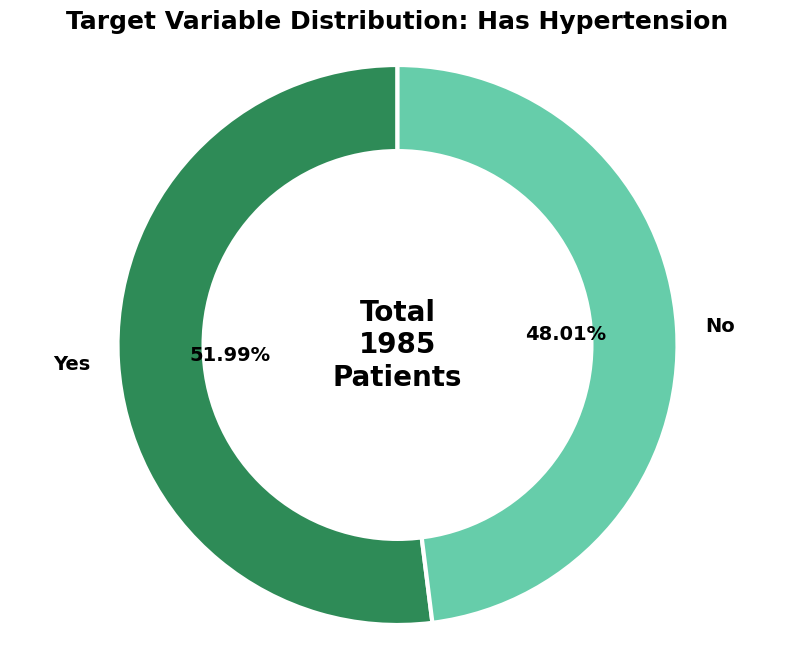

In [18]:
target_counts = df['Has_Hypertension'].value_counts()

colors = ['#66CDAA', '#2E8B57']
if target_counts.index[0] == 'Yes':
    colors = colors[::-1]

plt.figure(figsize=(10, 8))

plt.pie(target_counts,
        labels=target_counts.index,
        autopct='%.2f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 14, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 3})

center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

total_patients = len(df)
plt.text(0, 0, f'Total\n{total_patients}\nPatients',
         ha='center', va='center', fontsize=20, fontweight='bold')


plt.title('Target Variable Distribution: Has Hypertension', fontsize=18, fontweight='bold')
plt.axis('equal')
plt.show()

# Numerical Features EDA

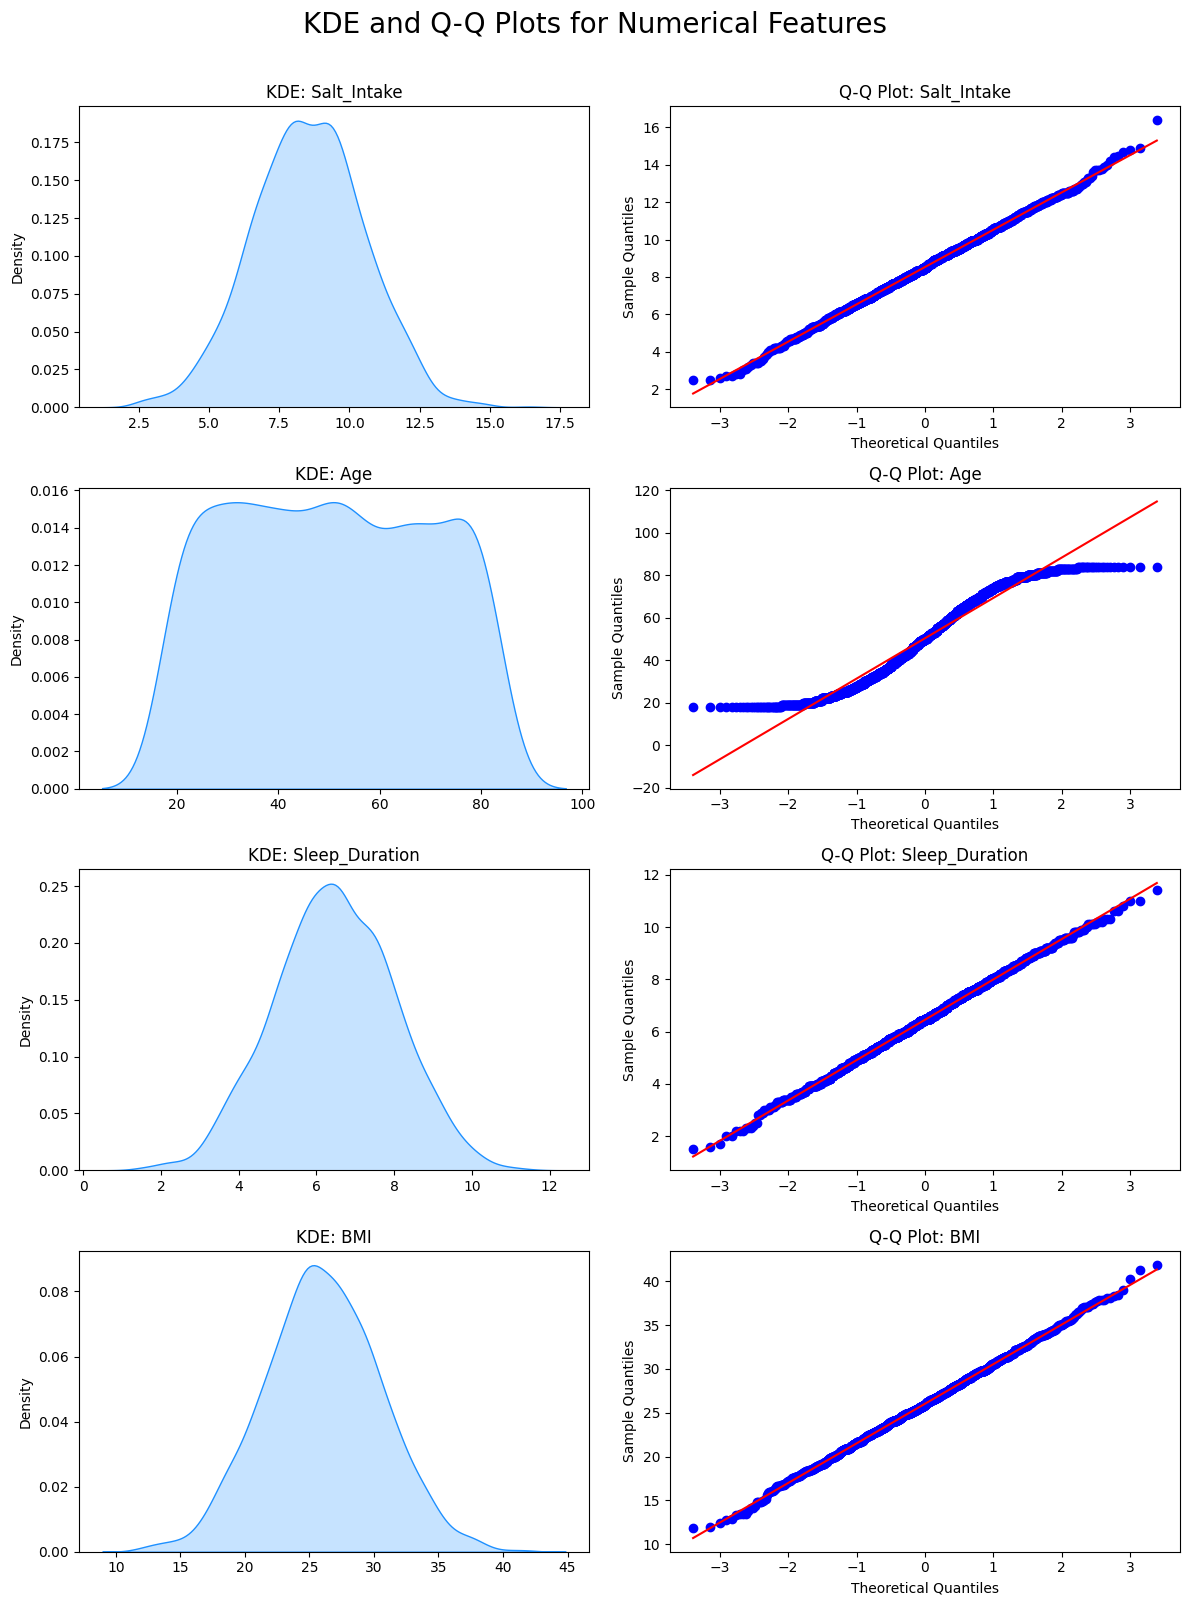

In [19]:
numerical_features = [
    'Salt_Intake', 'Age', 'Sleep_Duration', 'BMI'
]

fig, axes = plt.subplots(
    nrows=len(numerical_features),
    ncols=2,
    figsize=(12, 4 * len(numerical_features))
)

fig.suptitle('KDE and Q-Q Plots for Numerical Features', fontsize=20, y=1.0)

for i, col in enumerate(numerical_features):
    # --- KDE Plot (Left) ---
    ax_kde = axes[i, 0]
    sns.kdeplot(data=df, x=col, fill=True, ax=ax_kde, color='dodgerblue')
    ax_kde.set_title(f'KDE: {col}', fontsize=12)
    ax_kde.set_xlabel('')
    ax_kde.set_ylabel('Density')

    # --- Q-Q Plot (Right) ---
    ax_qq = axes[i, 1]
    stats.probplot(df[col].dropna(), dist="norm", plot=ax_qq)
    ax_qq.set_title(f'Q-Q Plot: {col}', fontsize=12)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

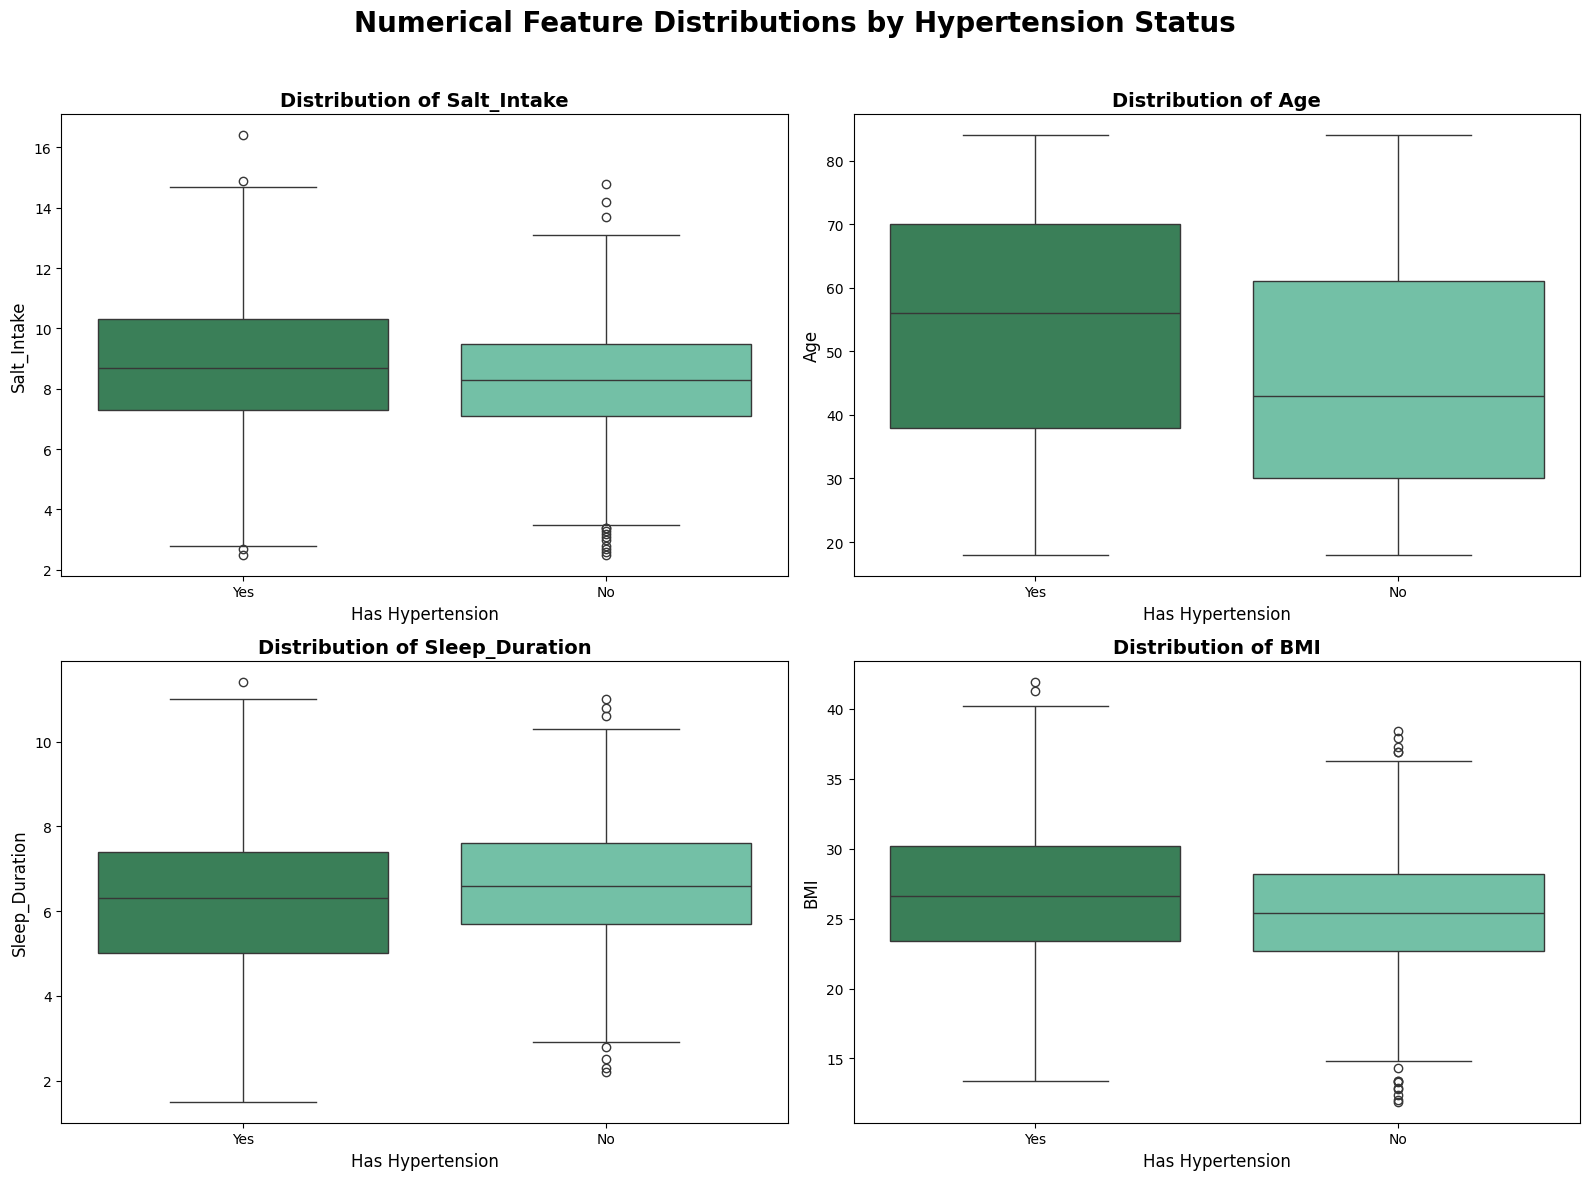

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

palette = {'No': '#66CDAA', 'Yes': '#2E8B57'}

for i, col in enumerate(numerical_features):
    sns.boxplot(ax=axes[i],
                data=df,
                x='Has_Hypertension',
                y=col,
                palette=palette)

    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Has Hypertension', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

plt.suptitle('Numerical Feature Distributions by Hypertension Status', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Encoding Target Feature

In [21]:
boolean_map = {'No': 0, 'Yes': 1}
df['Has_Hypertension'] = df['Has_Hypertension'].map(boolean_map)
print(df['Has_Hypertension'].head())

0    1
1    0
2    0
3    1
4    0
Name: Has_Hypertension, dtype: int64


In [22]:
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,No Medication,Yes,Low,Non-Smoker,1
1,32,11.7,10,Normal,5.4,23.4,No Medication,No,Low,Non-Smoker,0
2,78,9.5,3,Normal,7.1,18.7,No Medication,No,Moderate,Non-Smoker,0
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,1
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,0


# Train Test Split

In [23]:
X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Modeling - CATBoost + GridSearchCV

In [30]:
from catboost import CatBoostClassifier
categorical_features_names = ['BP_History', 'Medication','Family_History','Exercise_Level','Smoking_Status']

model = CatBoostClassifier(cat_features=categorical_features_names,
                           verbose=0,
                           random_state=42)

param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth': [5, 10],
    'l2_leaf_reg': [3, 5, 7],
    'subsample': [0.8, 1.0]
}


grid_search = GridSearchCV(estimator=model,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print("---------------------------------")
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print("---------------------------------")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Model Performance on the Test Set:")
print(f"Accuracy: {test_accuracy:.4f}")

KeyboardInterrupt: 

In [28]:
!pip install catboost

### Why We Chose CatBoost: The Specialist for Mixed Data 🚀

The Challenge: A Mix of Numbers and Text

Our dataset had a mix of data types:

* Numerical Features: like Age and BMI.
* Categorical Features: like BP_History and Medication.

Many machine learning models can only handle numbers, forcing us to manually convert our text categories first.

###The Solution: CatBoost's Built-in Superpower

Think of **CatBoost** (Categorical Boosting) as a **specialist translator**. While other models require you to translate your text data into numbers yourself (using One-Hot or Label Encoding), CatBoost has a world-class translator built right in.


You simply tell CatBoost, "Hey, these columns are my categories," and it handles the rest. It uses a very smart technique to automatically convert the text categories into meaningful numbers during training, which often leads to better results.

####The Main Benefits

* **Less Work, More Accuracy:** We didn't need to do complex preprocessing. We fed the data in its natural state, and the model's specialized handling often leads to higher accuracy.

* **Prevents Common Errors:** It avoids the pitfalls of simple Label Encoding (where a model might think 'High' > 'Good') and One-Hot Encoding (which can create too many new features).

* **Built to Avoid Overfitting:** Its internal method for handling categories is designed to be robust and prevent the model from "memorizing" the training data.
In short, for a dataset rich with categorical information like ours, CatBoost was the perfect tool for the j

# Classification Report

In [31]:
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))


Classification Report on Test Set:


NameError: name 'y_pred' is not defined

# Confusion Matrix and Analysis

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=2)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

NameError: name 'y_pred' is not defined

# Feature Importance

## 1. Using CAT Boost inbuilt-feature_importances_

In [33]:
feature_names = X_train.columns

importances = best_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Set2')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

NameError: name 'best_model' is not defined

## 2. Using SHAPley

In [34]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance (Mean |SHAP|)', fontsize=14)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

plt.figure(figsize=(10, 6))
plt.title('SHAP Summary Plot (Beeswarm)', fontsize=14)
shap.summary_plot(shap_values, X_test, show=True)

NameError: name 'best_model' is not defined

#Conclusion & Key Takeaways

This notebook successfully navigated the end-to-end machine learning workflow to build a highly accurate and interpretable model for **Hypertension Risk Prediction**. Starting from a raw dataset, we performed an in-depth exploratory data analysis (EDA), implemented a strategic imputation plan, and ultimately trained a CatBoost model that achieved exceptional performance.

The project is built on several key insights and decisions such as follows:

#### Context-Driven Imputation is Crucial
#### The Right Tool for the Job: CatBoost for Categorical Data
#### Beyond Prediction: From Black Box to Interpretable Insights with SHAP